<a href="https://colab.research.google.com/github/dayananathalih-prog/EstadisticaVerano2026/blob/main/Practica01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Problema 1
Un profesor intenta mostrar a sus estudiantes la importancia de los exámenes cortos, aun cuando el 90% de la calificación final esté determinada por los exámenes parciales. Él cree que cuanto más altas sean las calificaciones de los exámenes cortos, más alta será la calificación final. Seleccionó una muestra aleatoria de 15 estudiantes de su clase con los siguientes datos:

| Promedio de exámenes cortos | Promedio final |
|--------------|--------------|
| 59 | 64 |
| 92 | 84 |
| 72 | 77 |
| 90 | 80 |
| 95 | 77 |
| 87 | 81 |
| 89 | 80 |
| 77 | 84 |
| 76 | 80 |
| 65 | 69 |
| 97 | 83 |
| 42 | 40 |
| 94 | 78 |
| 62 | 65 |
| 91 | 90 |



In [ ]:
import pandas as pd

#  Esto es para cargar los datos
df = pd.DataFrame({
    "promedio_examenes_cortos": [59,92,72,90,95,87,89,77,76,65,97,42,94,62,91],
    "promedio_final": [64,84,77,80,77,81,80,84,80,69,83,40,78,65,90]
})

df

,promedio_examenes_cortos,promedio_final
0,59,64
1,92,84
2,72,77
3,90,80
4,95,77
5,87,81
6,89,80
7,77,84
8,76,80
9,65,69


1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).

In [ ]:
# Qué información tengo (x) Variable independiente
# Qué quiero predecir (y) Variable dependiente

Y = df["promedio_final"]
X = df["promedio_examenes_cortos"]

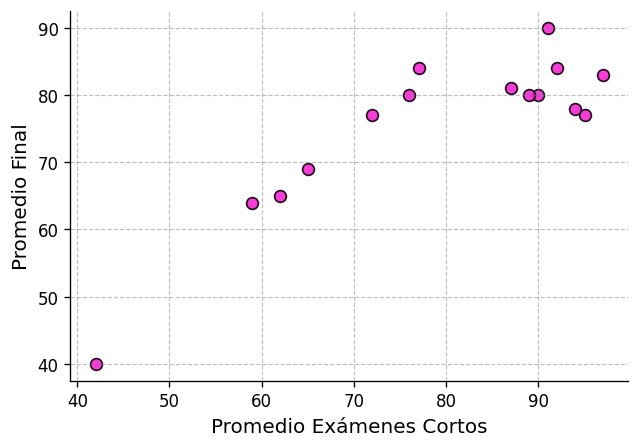

In [ ]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='#F527D3',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Promedio Exámenes Cortos', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Promedio Final', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

In [ ]:
# Importar la función pearsonr desde scipy.stats
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)

print(f"Coeficiente de correlaciòn: {r: 0.4f}")
print(f'valor_p: {valor_p: 0.4f}')

Coeficiente de correlaciòn:  0.8646
valor_p:  0.0000


In [ ]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,24.526822
promedio_examenes_cortos,0.643180


El modelo es:

$$
\hat{y}=24.5268+0.643180x
$$

donde $x$ es el promedio en exámenes cortos.

In [ ]:
# intervalos de confianza

modelo.conf_int(alpha=0.05)

,0,1
const,6.441997,42.611646
promedio_examenes_cortos,0.419219,0.867141


In [ ]:
24.5268+0.643180*(59)

62.47442

In [ ]:
# modelo.predict([1, x])

modelo.predict([1, 59])

array([62.47443345])

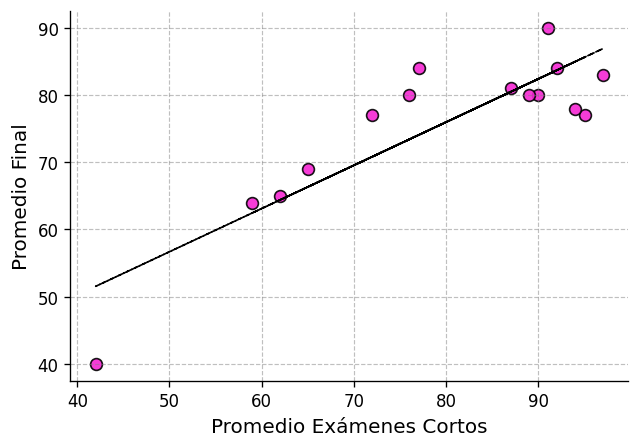

In [ ]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='#F527D3',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Promedio Exámenes Cortos', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Promedio Final', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

In [ ]:
residuales = modelo.resid

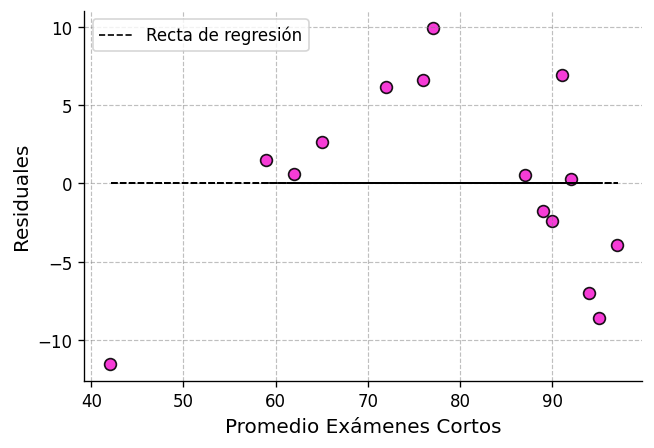

In [ ]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, residuales,      # <--------------------------------------------------------
    marker="o",       # forma: googlear "matplotlib.markers"
    color='#F527D3',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada * 0, # <---------------------------------------------------------
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Promedio Exámenes Cortos', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Residuales', # etiqueta del eje y #<-----------------------------------------
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    fontsize=10,
    loc='best'
)

valor-p (Shapiro) = 0.901827735700704


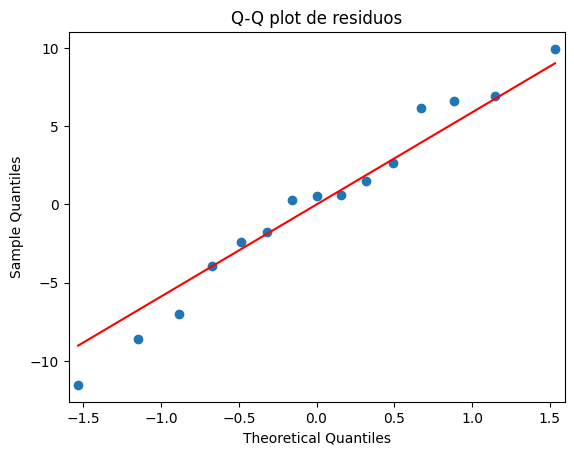

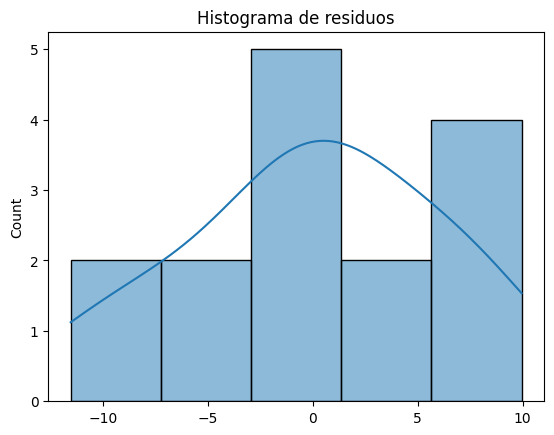

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# test de Shapiro-Wilk
# H0: Hay normalidad
# H1: No hay normalidad

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.2289



In [ ]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('''promedio_final ~ promedio_examenes_cortos''',data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
promedio_examenes_cortos,1.0,1538.228959,1538.228959,38.492412,0.000032
Residual,13.0,519.504375,39.961875,NaN,NaN
